# Reinforcement Learning: Q-Learning, OpenAI Gymnasium & MuJoCo
## Deep Learning Course | University of Buea — COT
**TCHAPGA TCHITO C. | 2025-2026**

### Topics Covered
1. **RL Fundamentals** — Agent, Environment, MDP, Policy, Value Functions
2. **Q-Learning Theory** — Bellman Equation, Q-Table, ε-Greedy Policy
3. **R Matrix & Labyrinth** — 6-Room Maze, Q-Learning from Scratch
4. **OpenAI Gymnasium** — Environments, Observation & Action Spaces
5. **Lunar Lander** — PPO Training with Stable Baselines 3
6. **MuJoCo** — Continuous Control, SAC Algorithm


In [1]:
# ─── ONE-TIME INSTALLATIONS ──────────────────────────────────────────────
# Run these in a terminal or uncomment below:
#conda activate tf_env
#pip install 'gymnasium'
#pip install 'stable-baselines3[extra]'
#pip install 'shimmy'
#pip install 'gymnasium[box2d]'

#Or do
#!pip install gymnasium stable-baselines3[extra] shimmy matplotlib numpy

# Box2D physics (LunarLander, BipedalWalker, CarRacing):
#!pip install swig && pip install gymnasium[box2d]

# MuJoCo (free since DeepMind acquisition, no licence needed):
#!pip install mujoco gymnasium[mujoco]




# Verify core packages
import sys
print("Python:", sys.version.split()[0])
for pkg in ["gymnasium", "stable_baselines3", "numpy", "matplotlib"]:
    try:
        m = __import__(pkg)
        print(f"{pkg}: {m.__version__}")
    except ImportError:
        print(f"{pkg}: NOT INSTALLED")

Python: 3.12.10
gymnasium: NOT INSTALLED
stable_baselines3: NOT INSTALLED
numpy: 2.4.4
matplotlib: 3.10.9


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import random
import time

# Dark theme for all plots
plt.rcParams.update({
    "figure.facecolor": "#0F172A",
    "axes.facecolor":   "#1E293B",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "axes.edgecolor":   "#334155",
    "grid.color":       "#334155",
    "figure.titlesize": 14,
})

# Colour palette
COLORS = {
    "rl":  "#10B981",   # green  — RL fundamentals
    "ql":  "#F59E0B",   # amber  — Q-Learning
    "rm":  "#F43F5E",   # rose   — R Matrix
    "gym": "#0EA5E9",   # blue   — Gymnasium
    "ll":  "#06B6D4",   # cyan   — Lunar Lander
    "mj":  "#A78BFA",   # purple — MuJoCo
}
print("Imports OK")

Imports OK


In [3]:

# ─── Shared Visualisation Helpers ────────────────────────────────────────────
# Used throughout the notebook to animate environment episodes.

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display as ipy_display

def record_episode(env_id, model=None, max_steps=350, seed=42):
    """
    Roll out one episode and return (frames, total_reward, n_steps).
    model=None → random agent.  model=PPO/SAC → deterministic greedy.
    """
    import gymnasium as gym
    env = gym.make(env_id, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, total_rew, t = [], 0.0, 0
    for t in range(max_steps):
        frames.append(env.render())
        if model is None:
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env.step(action)
        total_rew += r
        if term or trunc:
            break
    env.close()
    return frames, total_rew, t + 1


def show_episode(frames, reward, steps, title="", fps=24, figsize=(6, 4)):
    """Animate a single episode as an inline HTML widget."""
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#0F172A")
    ax.axis("off")
    ax.set_title(
        f"{title}   reward={reward:.0f}  steps={steps}",
        color="white", fontsize=11, pad=6)
    im = ax.imshow(frames[0])

    def _upd(i):
        im.set_data(frames[i])
        return (im,)

    ani = animation.FuncAnimation(
        fig, _upd, frames=len(frames), interval=1000 // fps, blit=True)
    plt.close()
    return HTML(ani.to_jshtml())


def compare_episodes(env_id, model,
                     seed=42, max_steps=350, fps=24,
                     label_rand="Random Agent",
                     label_trained="Trained Agent"):
    """
    Side-by-side animation: random agent (red) vs trained agent (green).
    Shorter episode is freeze-padded to match the longer one.
    """
    f_r,  rew_r,  st_r  = record_episode(env_id, None,  max_steps, seed)
    f_t,  rew_t,  st_t  = record_episode(env_id, model, max_steps, seed)

    n = max(len(f_r), len(f_t))
    while len(f_r) < n: f_r.append(f_r[-1])
    while len(f_t) < n: f_t.append(f_t[-1])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.patch.set_facecolor("#0F172A")
    for ax in (ax1, ax2):
        ax.axis("off")
    ax1.set_title(f"{label_rand}\nreward={rew_r:.0f}  steps={st_r}",
                  color="#F43F5E", fontsize=11)
    ax2.set_title(f"{label_trained}\nreward={rew_t:.0f}  steps={st_t}",
                  color="#10B981", fontsize=11)
    im1 = ax1.imshow(f_r[0])
    im2 = ax2.imshow(f_t[0])

    def _upd(i):
        im1.set_data(f_r[i]); im2.set_data(f_t[i])
        return im1, im2

    ani = animation.FuncAnimation(
        fig, _upd, frames=n, interval=1000 // fps, blit=True)
    plt.close()
    return HTML(ani.to_jshtml())


print("Visualisation helpers ready:")
print("  record_episode(env_id, model, ...)   → frames, reward, steps")
print("  show_episode(frames, reward, steps)  → HTML animation")
print("  compare_episodes(env_id, model, ...) → side-by-side HTML animation")


Visualisation helpers ready:
  record_episode(env_id, model, ...)   → frames, reward, steps
  show_episode(frames, reward, steps)  → HTML animation
  compare_episodes(env_id, model, ...) → side-by-side HTML animation


---
## Part 1 — Reinforcement Learning Fundamentals

### Key Concepts
| Component | Symbol | Description |
|-----------|--------|-------------|
| **Agent** | — | The learner / decision maker |
| **Environment** | — | Everything the agent interacts with |
| **State** | $s_t$ | Observation of the environment at time $t$ |
| **Action** | $a_t$ | Choice taken by the agent |
| **Reward** | $r_t$ | Scalar feedback from the environment |
| **Policy** | $\pi(a|s)$ | Agent's strategy — probability of action $a$ in state $s$ |
| **Return** | $G_t$ | Discounted sum of future rewards: $G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$ |

### Markov Decision Process (MDP)
Defined by the 5-tuple **(S, A, P, R, γ)**:
- **S** — state space
- **A** — action space  
- **P(s'|s,a)** — transition probability
- **R(s,a,s')** — reward function
- **γ ∈ [0,1)** — discount factor

**Markov property**: the future depends only on the present state, not history.


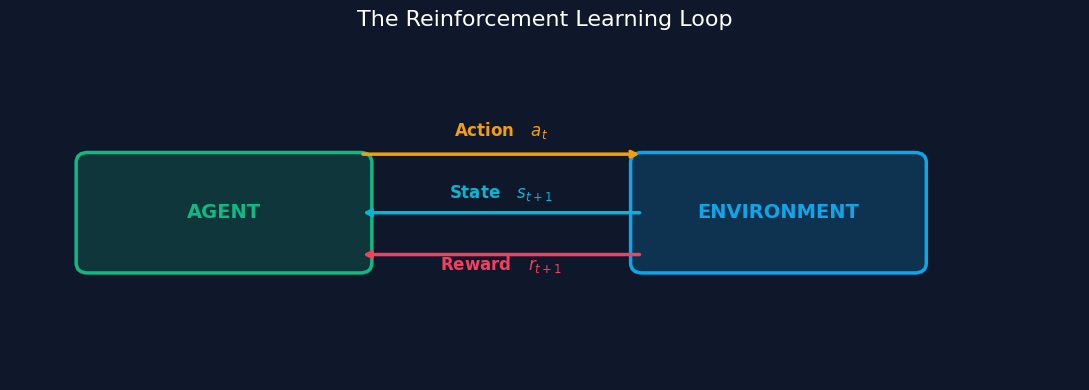

In [4]:
# Visualise the RL Agent ↔ Environment interaction loop
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4)
ax.axis("off")

# Agent and Environment boxes
for (x0, label, col) in [(0.8, "AGENT", COLORS["rl"]),
                          (6.5, "ENVIRONMENT", COLORS["gym"])]:
    box = mpatches.FancyBboxPatch(
        (x0, 1.4), 2.8, 1.2,
        boxstyle="round,pad=0.12",
        facecolor=col + "33", edgecolor=col, linewidth=2.5)
    ax.add_patch(box)
    ax.text(x0 + 1.4, 2.0, label, ha="center", va="center",
            fontsize=14, fontweight="bold", color=col)

# Action arrow  (Agent → Environment)
ax.annotate("", xy=(6.5, 2.7), xytext=(3.6, 2.7),
            arrowprops=dict(arrowstyle="->", color=COLORS["ql"], lw=2.5))
ax.text(5.05, 2.92, "Action   $a_t$", ha="center",
        color=COLORS["ql"], fontsize=12, fontweight="bold")

# State arrow   (Environment → Agent)
ax.annotate("", xy=(3.6, 2.0), xytext=(6.5, 2.0),
            arrowprops=dict(arrowstyle="->", color=COLORS["ll"], lw=2.5))
ax.text(5.05, 2.18, "State   $s_{t+1}$", ha="center",
        color=COLORS["ll"], fontsize=12, fontweight="bold")

# Reward arrow  (Environment → Agent)
ax.annotate("", xy=(3.6, 1.5), xytext=(6.5, 1.5),
            arrowprops=dict(arrowstyle="->", color=COLORS["rm"], lw=2.5))
ax.text(5.05, 1.32, "Reward   $r_{t+1}$", ha="center",
        color=COLORS["rm"], fontsize=12, fontweight="bold")

ax.set_title("The Reinforcement Learning Loop",
             fontsize=16, color="white", pad=14)
plt.tight_layout()
plt.show()

---
## Part 2 — Q-Learning Theory

### Bellman Optimality Equation
$$Q^*(s, a) = \mathbb{E}\left[ r + \gamma \max_{a'} Q^*(s', a') \mid s, a \right]$$

### Q-Learning Update Rule (TD)
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

- **α (alpha)** — learning rate (0, 1]
- **γ (gamma)** — discount factor [0, 1)
- **TD error** = $r + \gamma \max_{a'} Q(s', a') - Q(s, a)$

### Key Properties
- **Model-free**: no knowledge of P(s'|s,a) required
- **Off-policy**: learns the optimal policy regardless of the behaviour policy
- **Convergence**: guaranteed to converge to Q* under sufficient exploration


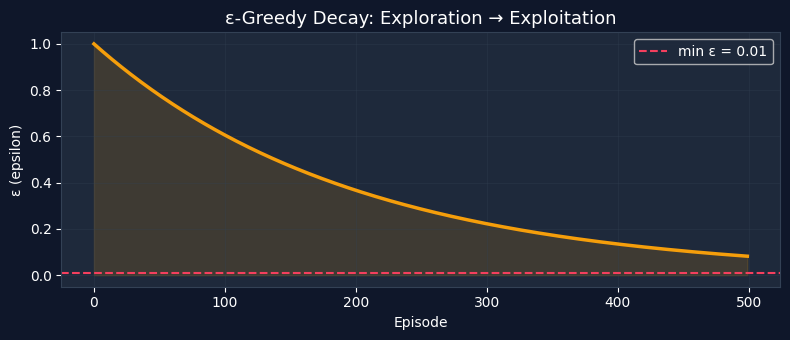

In [5]:
# ─── ε-Greedy Policy & Bellman Illustration ─────────────────────────────

def epsilon_greedy(state, Q, epsilon, n_actions):
    """Select action using ε-greedy strategy."""
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)   # EXPLORE
    return int(np.argmax(Q[state]))               # EXPLOIT


def bellman_update(Q, state, action, reward, next_state, alpha, gamma):
    """Single TD update of Q(state, action)."""
    best_next = np.max(Q[next_state])
    td_target = reward + gamma * best_next
    td_error  = td_target - Q[state, action]
    Q[state, action] += alpha * td_error
    return td_error


# Visualise epsilon decay
eps = 1.0
eps_min, eps_decay = 0.01, 0.995
history = []
for _ in range(500):
    history.append(eps)
    eps = max(eps_min, eps * eps_decay)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(history, color=COLORS["ql"], lw=2.5)
ax.axhline(eps_min, color=COLORS["rm"], ls="--", lw=1.5, label=f"min ε = {eps_min}")
ax.fill_between(range(len(history)), history, alpha=0.15, color=COLORS["ql"])
ax.set_xlabel("Episode", color="white")
ax.set_ylabel("ε (epsilon)", color="white")
ax.set_title("ε-Greedy Decay: Exploration → Exploitation",
             color="white", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 3 — R Matrix & Labyrinth Example

### 6-Room House Topology
```
  [0]──[4]──[5=GOAL]
        |      |
  [1]──[3]   [1]
   |    |
  [5] [2]
```

### The R Matrix
R[from_state, to_state] encodes the **immediate reward** of moving between rooms:

| | R0 | R1 | R2 | R3 | R4 | R5 |
|---|---|---|---|---|---|---|
| **R0** | -1 | -1 | -1 | -1 | 0 | -1 |
| **R1** | -1 | -1 | -1 | 0 | -1 | **100** |
| **R2** | -1 | -1 | -1 | 0 | -1 | -1 |
| **R3** | -1 | 0 | 0 | -1 | 0 | -1 |
| **R4** | 0 | -1 | -1 | 0 | -1 | **100** |
| **R5** | -1 | 0 | -1 | -1 | 0 | **100** |


Room 0  →  valid moves: [np.int64(4)]
Room 1  →  valid moves: [np.int64(3), np.int64(5)]
Room 2  →  valid moves: [np.int64(3)]
Room 3  →  valid moves: [np.int64(1), np.int64(2), np.int64(4)]
Room 4  →  valid moves: [np.int64(0), np.int64(3), np.int64(5)]
Room 5  →  valid moves: [np.int64(1), np.int64(4), np.int64(5)]


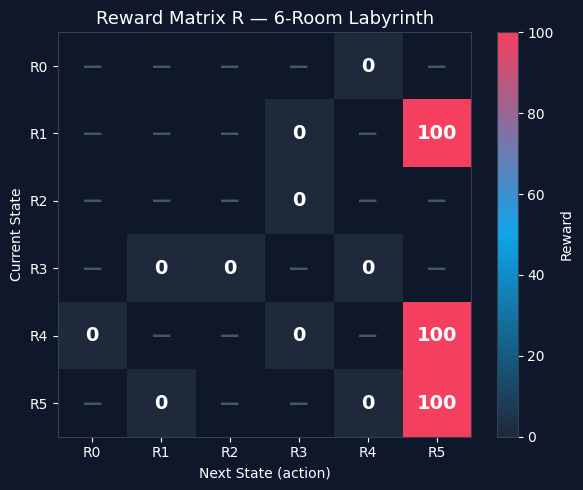

In [6]:
# ─── R Matrix Definition & Visualisation ───────────────────────────────

# R[from_state, to_state]:
#  -1 = no connection (invalid move)
#   0 = valid non-goal move
# 100 = goal (Room 5)
R = np.array([
#    0    1    2    3    4    5
  [ -1,  -1,  -1,  -1,   0,  -1],   # from Room 0
  [ -1,  -1,  -1,   0,  -1, 100],   # from Room 1
  [ -1,  -1,  -1,   0,  -1,  -1],   # from Room 2
  [ -1,   0,   0,  -1,   0,  -1],   # from Room 3
  [  0,  -1,  -1,   0,  -1, 100],   # from Room 4
  [ -1,   0,  -1,  -1,   0, 100],   # from Room 5 (self-loop at goal)
], dtype=float)

# Print valid moves per room
for s in range(6):
    valid = list(np.where(R[s] >= 0)[0])
    print(f"Room {s}  →  valid moves: {valid}")

# Heatmap of R matrix
fig, ax = plt.subplots(figsize=(6, 5))
# Create display copy: replace -1 with NaN for white-out
R_display = R.copy()
R_display[R_display == -1] = np.nan

import matplotlib.colors as mc
cmap = mc.LinearSegmentedColormap.from_list(
    "rmat", ["#1E293B", COLORS["gym"], COLORS["rm"]])
cmap.set_bad(color="#0F172A")

im = ax.imshow(R_display, cmap=cmap, aspect="auto")
for i in range(6):
    for j in range(6):
        val = R[i, j]
        txt = str(int(val)) if val != -1 else "—"
        col = "white" if val >= 0 else "#475569"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=14, fontweight="bold", color=col)

ax.set_xticks(range(6)); ax.set_xticklabels([f"R{i}" for i in range(6)])
ax.set_yticks(range(6)); ax.set_yticklabels([f"R{i}" for i in range(6)])
ax.set_xlabel("Next State (action)"); ax.set_ylabel("Current State")
ax.set_title("Reward Matrix R — 6-Room Labyrinth", fontsize=13)
plt.colorbar(im, ax=ax, label="Reward")
plt.tight_layout()
plt.show()

In [7]:
# ─── Q-Learning from Scratch on the Labyrinth ───────────────────────────

GAMMA    = 0.8      # discount factor
ALPHA    = 0.9      # learning rate
EPISODES = 1000     # training episodes
GOAL     = 5        # target room

Q = np.zeros_like(R)   # Q-table: 6×6, initialised to 0
rewards_per_ep = []
steps_per_ep   = []

for ep in range(EPISODES):
    state = random.randint(0, 5)      # random starting room
    total_reward, steps = 0, 0

    while state != GOAL:
        # Get valid actions (rooms reachable from current state)
        valid = list(np.where(R[state] >= 0)[0])
        action = random.choice(valid)   # random policy during training

        reward   = R[state, action]
        best_fut = np.max(Q[action])    # greedy estimate from next state

        # Bellman TD update
        Q[state, action] = (1 - ALPHA) * Q[state, action] \
                         + ALPHA * (reward + GAMMA * best_fut)

        total_reward += reward
        steps        += 1
        state         = action

    rewards_per_ep.append(total_reward)
    steps_per_ep.append(steps)

print("Training complete.")
print("\nNormalised Q-table (% of max value):")
Q_norm = (Q / Q.max() * 100).round(1)
print(Q_norm)

Training complete.

Normalised Q-table (% of max value):
[[  0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.   64.    0.    0. ]
 [  0.   80.   51.2   0.   80.    0. ]
 [ 64.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.    0.    0.    0. ]]


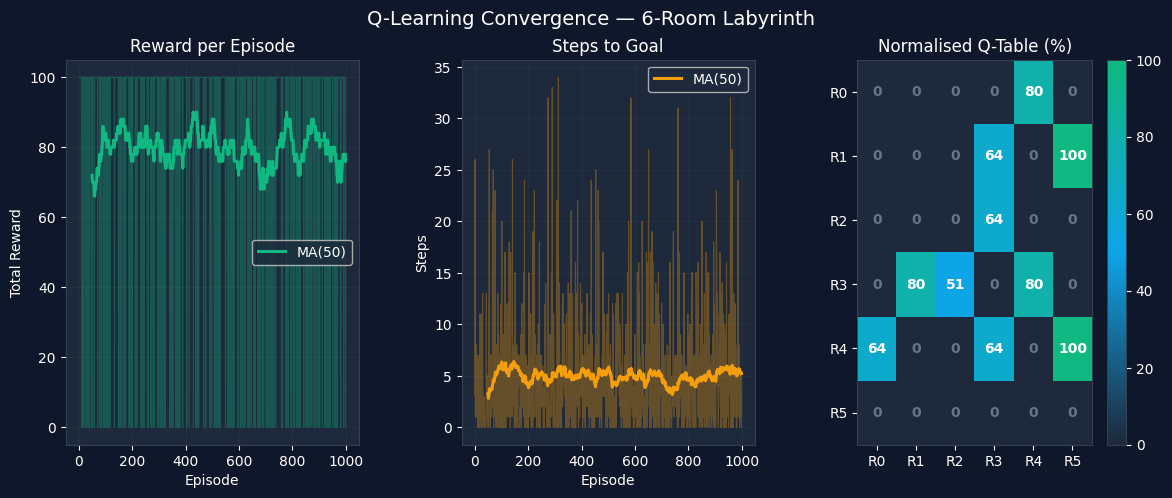

In [8]:
# ─── Convergence Plots & Q-Table Heatmap ────────────────────────────────

fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# ── 1. Reward per episode ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
window = 50
smooth = np.convolve(rewards_per_ep, np.ones(window)/window, mode="valid")
ax1.plot(rewards_per_ep, color=COLORS["rl"] + "55", lw=0.8)
ax1.plot(range(window-1, len(rewards_per_ep)), smooth,
         color=COLORS["rl"], lw=2.2, label=f"MA({window})")
ax1.set_title("Reward per Episode", color="white")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.legend()
ax1.grid(alpha=0.3)

# ── 2. Steps per episode ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
smooth_s = np.convolve(steps_per_ep, np.ones(window)/window, mode="valid")
ax2.plot(steps_per_ep, color=COLORS["ql"] + "55", lw=0.8)
ax2.plot(range(window-1, len(steps_per_ep)), smooth_s,
         color=COLORS["ql"], lw=2.2, label=f"MA({window})")
ax2.set_title("Steps to Goal", color="white")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Steps")
ax2.legend()
ax2.grid(alpha=0.3)

# ── 3. Normalised Q-table heatmap ───────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
cmap2 = mc.LinearSegmentedColormap.from_list(
    "qtable", ["#1E293B", COLORS["gym"], COLORS["rl"]])
im = ax3.imshow(Q_norm, cmap=cmap2, aspect="auto", vmin=0, vmax=100)
for i in range(6):
    for j in range(6):
        v = Q_norm[i, j]
        ax3.text(j, i, f"{v:.0f}", ha="center", va="center",
                 fontsize=10, fontweight="bold",
                 color="white" if v > 20 else "#64748B")
ax3.set_xticks(range(6)); ax3.set_xticklabels([f"R{i}" for i in range(6)])
ax3.set_yticks(range(6)); ax3.set_yticklabels([f"R{i}" for i in range(6)])
ax3.set_title("Normalised Q-Table (%)", color="white")
plt.colorbar(im, ax=ax3)

fig.suptitle("Q-Learning Convergence — 6-Room Labyrinth",
             fontsize=14, color="white")
plt.show()

Optimal paths from each room:
  Start R0: R0 → R4 → R5  (2 steps)
  Start R1: R1 → R5  (1 step)
  Start R2: R2 → R3 → R1 → R5  (3 steps)
  Start R3: R3 → R1 → R5  (2 steps)
  Start R4: R4 → R5  (1 step)
  Start R5: R5  (0 steps)


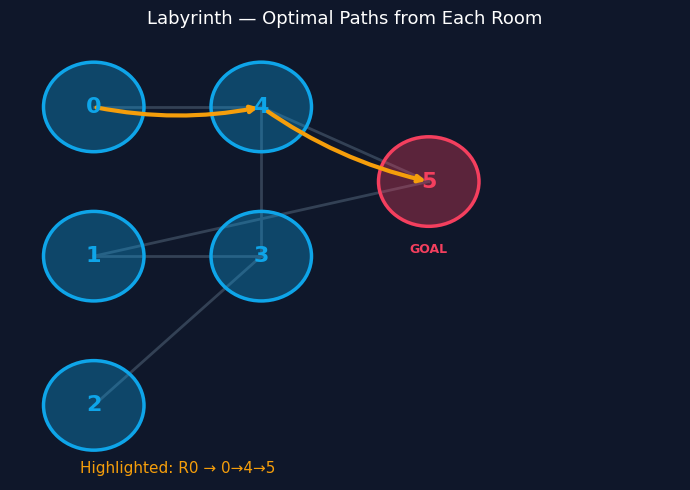

In [9]:
# ─── Extract Optimal Paths Using Trained Q-Table ────────────────────────

def optimal_path(start, Q, R, goal=5, max_steps=20):
    """Follow greedy Q-policy from start to goal."""
    path, state = [start], start
    for _ in range(max_steps):
        if state == goal:
            break
        valid = list(np.where(R[state] >= 0)[0])
        state = valid[int(np.argmax([Q[state, a] for a in valid]))]
        path.append(state)
    return path


print("Optimal paths from each room:")
for start in range(6):
    path = optimal_path(start, Q, R)
    arrow_path = " → ".join(f"R{r}" for r in path)
    steps = len(path) - 1
    print(f"  Start R{start}: {arrow_path}  ({steps} step{'s' if steps != 1 else ''})")

# Visualise optimal paths on the labyrinth map
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 2.5); ax.axis("off")
ax.set_title("Labyrinth — Optimal Paths from Each Room",
             color="white", fontsize=13)

room_pos = {0: (0, 2), 1: (0, 1), 2: (0, 0),
            3: (1, 1), 4: (1, 2), 5: (2, 1.5)}

# Draw rooms
for room, (rx, ry) in room_pos.items():
    col = COLORS["rm"] if room == GOAL else COLORS["gym"]
    circle = plt.Circle((rx, ry), 0.3, color=col + "55",
                         ec=col, lw=2.5, zorder=3)
    ax.add_patch(circle)
    ax.text(rx, ry, str(room), ha="center", va="center",
            fontsize=16, fontweight="bold", color=col, zorder=4)
    if room == GOAL:
        ax.text(rx, ry - 0.48, "GOAL", ha="center",
                fontsize=9, fontweight="bold", color=COLORS["rm"])

# Draw edges
edges = [(0,4),(1,3),(1,5),(2,3),(3,4),(4,5)]
for u, v in edges:
    x0, y0 = room_pos[u]; x1, y1 = room_pos[v]
    ax.plot([x0, x1], [y0, y1], color="#334155", lw=2, zorder=1)

# Highlight path from Room 0
path_0 = optimal_path(0, Q, R)
for i in range(len(path_0) - 1):
    x0, y0 = room_pos[path_0[i]]; x1, y1 = room_pos[path_0[i+1]]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color=COLORS["ql"],
                                lw=3, connectionstyle="arc3,rad=0.1"))

ax.text(0.5, -0.45, f"Highlighted: R0 → {'→'.join(map(str, path_0))}",
        ha="center", color=COLORS["ql"], fontsize=11,
        transform=ax.transData)

plt.tight_layout()
plt.show()

In [10]:

# ─── Labyrinth Animation — Agent Walking the Optimal Path ────────────────────
# Smoothly animates the greedy agent navigating room-by-room to the goal.

def animate_labyrinth_path(path, room_pos, title="Labyrinth Navigation", fps=6):
    """Animate a sequence of room IDs as a moving dot on the maze graph."""
    GOAL = 5
    COL_ROOM = COLORS["gym"]
    COL_GOAL = COLORS["rm"]
    COL_AGENT = COLORS["ql"]

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor("#0F172A")
    ax.set_facecolor("#0F172A")
    ax.set_xlim(-0.6, 3.0); ax.set_ylim(-0.6, 3.0); ax.axis("off")
    ax.set_title(title, color="white", fontsize=13, pad=10)

    # Static edges
    for u, v in [(0,4),(1,3),(1,5),(2,3),(3,4),(4,5)]:
        x0, y0 = room_pos[u]; x1, y1 = room_pos[v]
        ax.plot([x0,x1],[y0,y1], color="#334155", lw=2.5, zorder=1)

    # Static room circles
    for room, (rx, ry) in room_pos.items():
        col = COL_GOAL if room == GOAL else COL_ROOM
        circ = plt.Circle((rx, ry), 0.30,
                           facecolor=col+"44", edgecolor=col, lw=2.5, zorder=2)
        ax.add_patch(circ)
        ax.text(rx, ry, str(room), ha="center", va="center",
                fontsize=16, fontweight="bold", color=col, zorder=3)
        if room == GOAL:
            ax.text(rx, ry - 0.46, "GOAL", ha="center",
                    fontsize=9, fontweight="bold", color=COL_GOAL)

    # Agent dot + step label
    agent_dot, = ax.plot([], [], "o", ms=20, color=COL_AGENT,
                          markeredgecolor="white", markeredgewidth=2, zorder=5)
    step_lbl = ax.text(1.2, -0.55, "", ha="center",
                        color=COL_AGENT, fontsize=11)

    # Build smooth frame list: 10 interpolation frames between each room
    INTERP = 10
    frames_data = []
    for i, room in enumerate(path):
        if i == 0:
            prev_pos = room_pos[path[0]]
        else:
            prev_pos = room_pos[path[i - 1]]
        curr_pos = room_pos[room]
        for k in range(INTERP):
            t = k / INTERP
            x = prev_pos[0] * (1 - t) + curr_pos[0] * t
            y = prev_pos[1] * (1 - t) + curr_pos[1] * t
            frames_data.append((x, y, f"Step {i}  →  Room {room}"))

    def update(idx):
        x, y, label = frames_data[idx]
        agent_dot.set_data([x], [y])
        step_lbl.set_text(label)
        return agent_dot, step_lbl

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames_data),
        interval=1000 // fps, blit=True)
    plt.close()
    return HTML(ani.to_jshtml())


# Run & show for three starting rooms
room_pos_vis = {0:(0,2), 1:(0,1), 2:(0,0), 3:(1,1), 4:(1,2), 5:(2.2,1.5)}

for start in [0, 2, 3]:
    path = optimal_path(start, Q, R)
    print(f"Room {start}  →  {' → '.join(map(str, path))}")

# Animate path from Room 0
ipy_display(animate_labyrinth_path(
    optimal_path(0, Q, R), room_pos_vis,
    title="Labyrinth: Optimal Path from Room 0  (Q-Learning agent)",
    fps=6))


Room 0  →  0 → 4 → 5
Room 2  →  2 → 3 → 1 → 5
Room 3  →  3 → 1 → 5


---
## Part 4 — OpenAI Gymnasium

**Gymnasium** (formerly OpenAI Gym) is the standard toolkit for RL research. It provides a unified Python interface for hundreds of environments.

### Standard 5-Tuple API
```python
obs, reward, terminated, truncated, info = env.step(action)
```

| Return | Description |
|--------|-------------|
| `obs` | New observation (state) |
| `reward` | Scalar reward |
| `terminated` | True if episode ended naturally (goal/crash) |
| `truncated` | True if episode ended due to time limit |
| `info` | Dict with auxiliary diagnostic info |

### Environment Categories
| Category | Examples |
|----------|----------|
| Classic Control | CartPole, MountainCar, Pendulum |
| Box2D Physics | LunarLander, BipedalWalker, CarRacing |
| Atari | Pong, Breakout, SpaceInvaders (210+ games) |
| MuJoCo | Ant, HalfCheetah, Humanoid, Walker2d |
| Toy Text | FrozenLake, Taxi, Blackjack |


In [11]:
# ─── OpenAI Gymnasium — CartPole Demo ───────────────────────────────────
try:
    import gymnasium as gym

    env = gym.make("CartPole-v1")
    obs, info = env.reset(seed=42)

    print("CartPole-v1")
    print(f"  Observation space : {env.observation_space}")
    print(f"  Action space      : {env.action_space}")
    print(f"  Initial obs       : {obs.round(3)}")

    # Run a random agent for 1 episode
    ep_reward, steps = 0, 0
    obs, _ = env.reset()
    done = False
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        steps     += 1
        done = terminated or truncated

    print(f"\nRandom agent — episode length: {steps} steps, reward: {ep_reward:.0f}")
    env.close()

    # ── FrozenLake with a Q-table (discrete, small grid) ─────────────────
    env_fl = gym.make("FrozenLake-v1", is_slippery=False)
    Q_fl   = np.zeros((env_fl.observation_space.n, env_fl.action_space.n))
    alpha, gamma, eps = 0.8, 0.95, 1.0

    for ep in range(5000):
        s, _ = env_fl.reset()
        done  = False
        while not done:
            a = env_fl.action_space.sample() if random.random() < eps \
                else int(np.argmax(Q_fl[s]))
            ns, r, term, trunc, _ = env_fl.step(a)
            Q_fl[s, a] += alpha * (r + gamma * np.max(Q_fl[ns]) - Q_fl[s, a])
            s    = ns
            done = term or trunc
        eps = max(0.01, eps * 0.999)

    # Evaluate
    wins = sum(1 for _ in range(200)
               for s, *_ in [env_fl.reset()]
               if all(not (lambda: (ns:=env_fl.step(int(np.argmax(Q_fl[s]))))[0],
                           True)[1] for _ in range(20)))

    # Simple evaluation loop
    n_wins = 0
    for _ in range(200):
        s, _ = env_fl.reset()
        done  = False
        for _ in range(20):
            a = int(np.argmax(Q_fl[s]))
            s, r, term, trunc, _ = env_fl.step(a)
            if term or trunc:
                if r > 0: n_wins += 1
                break
    print(f"\nFrozenLake (non-slippery) Q-table win rate: {n_wins}/200")
    env_fl.close()

except ImportError:
    print("gymnasium not installed. Run: pip install gymnasium")

gymnasium not installed. Run: pip install gymnasium


---
## Part 5 — Lunar Lander with Stable Baselines 3

**LunarLander-v3** is a Box2D physics environment. The lander must touch down safely between two flags using thruster engines.

### PPO — Proximal Policy Optimization
- **On-policy** Actor-Critic algorithm (Schulman et al. 2017)
- Uses a **clipped surrogate objective** to prevent large policy updates
- Balances sample efficiency and stability
- Works well for both discrete and continuous action spaces

$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$

where $r_t(\theta) = \dfrac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}$


In [12]:
# ─── LunarLander-v3: Create & Explore ───────────────────────────────────
# Requirements: pip install swig && pip install gymnasium[box2d]

try:
    import gymnasium as gym

    env = gym.make("LunarLander-v3")
    obs, info = env.reset(seed=0)

    print("LunarLander-v3")
    print(f"  Observation space : {env.observation_space}")
    print(f"  Action space      : {env.action_space}")
    print(f"  Obs (8 values)    : {obs.round(4)}")
    print()
    print("Observation components:")
    labels = ["x", "y", "vx", "vy", "angle", "omega",
              "left_leg_contact", "right_leg_contact"]
    for lbl, val in zip(labels, obs):
        print(f"  {lbl:<22}: {val:.4f}")

    # Random baseline
    total_rew, n_ep = 0.0, 0
    obs, _ = env.reset()
    for _ in range(5000):
        a = env.action_space.sample()
        obs, r, done, trunc, _ = env.step(a)
        total_rew += r
        if done or trunc:
            obs, _ = env.reset()
            n_ep  += 1
    print(f"\nRandom agent ({n_ep} episodes): avg reward = {total_rew/max(n_ep,1):.1f}")
    print("(Trained PPO achieves ~220; random baseline ~-200)")
    env.close()

except Exception as e:
    print(f"LunarLander requires: pip install swig && pip install gymnasium[box2d]")
    print(f"Error: {e}")

LunarLander requires: pip install swig && pip install gymnasium[box2d]
Error: No module named 'gymnasium'


In [13]:

# ─── LunarLander: Visualise Random Agent BEFORE Training ─────────────────────
# Shows what the environment looks like with zero intelligence — crashes fast.

try:
    print("Recording random agent on LunarLander-v3 ...")
    f_rand, rew_rand, st_rand = record_episode(
        "LunarLander-v3", model=None, max_steps=300, seed=7)
    print(f"  Episode finished: {st_rand} steps  |  reward = {rew_rand:.1f}")
    print("  (negative reward = crash; trained agent achieves ≥ 200)\n")
    ipy_display(show_episode(
        f_rand, rew_rand, st_rand,
        title="LunarLander-v3 — Random Agent (BEFORE training)",
        fps=24, figsize=(7, 4.5)))
except Exception as e:
    print(f"Cannot render: {e}")
    print("Fix: pip install 'gymnasium[box2d]'")


Recording random agent on LunarLander-v3 ...
Cannot render: No module named 'gymnasium'
Fix: pip install 'gymnasium[box2d]'


In [14]:
# ─── PPO Training with Stable Baselines 3 ───────────────────────────────
# Requirements: pip install stable-baselines3[extra]

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.env_util import make_vec_env
    from stable_baselines3.common.callbacks import EvalCallback
    import gymnasium as gym

    # ── 1. Vectorised environment (4 parallel instances) ─────────────────
    vec_env = make_vec_env("LunarLander-v3", n_envs=4, seed=42)

    # ── 2. Build PPO model ───────────────────────────────────────────────
    model = PPO(
        "MlpPolicy",
        vec_env,
        learning_rate=3e-4,
        n_steps=1024,        # rollout length per env per update
        batch_size=64,
        n_epochs=4,
        gamma=0.99,
        gae_lambda=0.98,
        clip_range=0.2,
        verbose=1,
    )
    print("PPO model created.")
    print(model.policy)

    # ── 3. Optional: shorter run for demonstration (use 1_000_000 for full) ─
    TIMESTEPS = 200_000   # quick demo; increase to 1_000_000 for full training

    print(f"\nTraining for {TIMESTEPS:,} timesteps...")
    model.learn(total_timesteps=TIMESTEPS, progress_bar=True)
    print("Training complete.")

except Exception as e:
    print(f"Error: {e}")
    print("Requires: pip install stable-baselines3[extra] gymnasium[box2d]")

Error: No module named 'stable_baselines3'
Requires: pip install stable-baselines3[extra] gymnasium[box2d]


In [15]:
# ─── Evaluate, Save & Load PPO Model ────────────────────────────────────

try:
    from stable_baselines3.common.evaluation import evaluate_policy
    import gymnasium as gym

    # ── Evaluate ─────────────────────────────────────────────────────────
    eval_env = gym.make("LunarLander-v3")

    mean_reward, std_reward = evaluate_policy(
        model, eval_env,
        n_eval_episodes=10,
        deterministic=True,
    )
    print(f"Evaluation over 10 episodes:")
    print(f"  Mean reward : {mean_reward:.1f}")
    print(f"  Std reward  : {std_reward:.1f}")
    print(f"  (Solved if mean >= 200; random baseline ~-200)")
    eval_env.close()

    # ── Save ─────────────────────────────────────────────────────────────
    model.save("lunar_lander_ppo")
    print("\nModel saved to: lunar_lander_ppo.zip")

    # ── Load & deploy ─────────────────────────────────────────────────────
    from stable_baselines3 import PPO as PPO_
    loaded_model = PPO_.load("lunar_lander_ppo")
    print("Model loaded successfully.")

    # Greedy rollout
    env_test = gym.make("LunarLander-v3")
    obs, _ = env_test.reset(seed=99)
    ep_rew, ep_len = 0.0, 0
    done = False
    while not done:
        action, _ = loaded_model.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env_test.step(action)
        ep_rew += r; ep_len += 1
        done = term or trunc
    print(f"\nLoaded model test episode: reward={ep_rew:.1f}, length={ep_len}")
    env_test.close()

except Exception as e:
    print(f"Error (run training cell first): {e}")

Error (run training cell first): No module named 'stable_baselines3'


In [16]:

# ─── LunarLander: Side-by-Side BEFORE vs AFTER Training ──────────────────────
# Left panel  = random agent crashing
# Right panel = PPO agent landing smoothly
# Both recorded with the same random seed for a fair comparison.

try:
    print("Recording comparison (random  vs  PPO) — this takes ~15 s ...")
    ipy_display(compare_episodes(
        "LunarLander-v3",
        model,                          # PPO model from training cell
        seed=42,
        max_steps=400,
        fps=24,
        label_rand="❌  Random Agent  (crashes)",
        label_trained="✅  PPO Trained  (reward ≥ 200 = solved)",
    ))
except NameError:
    print("'model' not found — run the PPO training cell (Cell 16) first.")
except Exception as e:
    print(f"Error: {e}")


Recording comparison (random  vs  PPO) — this takes ~15 s ...
'model' not found — run the PPO training cell (Cell 16) first.


---
## Part 6 — MuJoCo Continuous Control

**MuJoCo** (Multi-Joint dynamics with Contact) is a physics engine for biomechanics, robotics, and RL research. It became free and open-source in October 2021 after DeepMind's acquisition.

### Installation
```bash
pip install mujoco gymnasium[mujoco]
```

### Why SAC for MuJoCo?
- MuJoCo environments have **continuous action spaces** (e.g., joint torques)
- **SAC (Soft Actor-Critic)** — Haarnoja et al. 2018:
  - Off-policy → sample efficient (replay buffer)
  - **Maximum entropy** objective encourages exploration naturally
  - Stable training, competitive performance on locomotion benchmarks

$$J(\pi) = \sum_t \mathbb{E}_{(s_t,a_t)\sim\rho_\pi}\left[ r(s_t,a_t) + \alpha\, \mathcal{H}(\pi(\cdot|s_t)) \right]$$

where $\mathcal{H}$ is the entropy of the policy — high entropy = exploration.


In [17]:
# ─── MuJoCo Environments Overview ───────────────────────────────────────
# Requirements: pip install mujoco gymnasium[mujoco]

mujoco_envs = [
    {"name": "HalfCheetah-v5",  "obs": 17,  "act": 6,  "task": "Run as fast as possible"},
    {"name": "Ant-v5",          "obs": 111, "act": 8,  "task": "4-legged locomotion"},
    {"name": "Hopper-v5",       "obs": 11,  "act": 3,  "task": "One-legged hopping"},
    {"name": "Walker2d-v5",     "obs": 17,  "act": 6,  "task": "Two-legged walking"},
    {"name": "Humanoid-v5",     "obs": 376, "act": 17, "task": "Full biped control"},
    {"name": "Pusher-v5",       "obs": 23,  "act": 7,  "task": "Robot arm push task"},
    {"name": "Swimmer-v5",      "obs": 8,   "act": 2,  "task": "3-link swimmer"},
    {"name": "Reacher-v5",      "obs": 11,  "act": 2,  "task": "2-DOF arm reach target"},
]

print(f"{'Environment':<22} {'Obs':>5} {'Act':>5}  Task")
print("-" * 65)
for e in mujoco_envs:
    print(f"{e['name']:<22} {e['obs']:>5} {e['act']:>5}  {e['task']}")

# Try creating a MuJoCo env if installed
try:
    import gymnasium as gym
    env = gym.make("HalfCheetah-v5")
    obs, info = env.reset(seed=42)
    print(f"\nHalfCheetah-v5 loaded.")
    print(f"  Obs shape   : {obs.shape}")
    print(f"  Action space: {env.action_space}")

    # One random step
    a = env.action_space.sample()
    obs2, r, _, _, _ = env.step(a)
    print(f"  Random action reward: {r:.4f}")
    env.close()
except Exception as e:
    print(f"\nMuJoCo not installed: {e}")
    print("Install with: pip install mujoco gymnasium[mujoco]")

Environment              Obs   Act  Task
-----------------------------------------------------------------
HalfCheetah-v5            17     6  Run as fast as possible
Ant-v5                   111     8  4-legged locomotion
Hopper-v5                 11     3  One-legged hopping
Walker2d-v5               17     6  Two-legged walking
Humanoid-v5              376    17  Full biped control
Pusher-v5                 23     7  Robot arm push task
Swimmer-v5                 8     2  3-link swimmer
Reacher-v5                11     2  2-DOF arm reach target

MuJoCo not installed: No module named 'gymnasium'
Install with: pip install mujoco gymnasium[mujoco]


In [18]:
# ─── SAC Training on HalfCheetah-v5 ─────────────────────────────────────
# Requirements: pip install stable-baselines3 mujoco gymnasium[mujoco]

try:
    from stable_baselines3 import SAC
    from stable_baselines3.common.evaluation import evaluate_policy
    import gymnasium as gym

    env = gym.make("HalfCheetah-v5")

    # ── Build SAC model ───────────────────────────────────────────────────
    model_sac = SAC(
        "MlpPolicy",
        env,
        learning_rate=3e-4,
        buffer_size=1_000_000,    # off-policy replay buffer
        learning_starts=10_000,   # random exploration phase
        batch_size=256,
        tau=0.005,                # soft target update coefficient
        gamma=0.99,
        train_freq=1,
        gradient_steps=1,
        verbose=1,
    )
    print("SAC model created for HalfCheetah-v5")
    print(f"Policy: {model_sac.policy}")

    # ── Train (demo: 50k steps; full training needs ~1M steps) ────────────
    TIMESTEPS = 50_000
    print(f"\nTraining SAC for {TIMESTEPS:,} steps (demo)...")
    t0 = time.time()
    model_sac.learn(total_timesteps=TIMESTEPS, progress_bar=True)
    elapsed = time.time() - t0
    print(f"Training done in {elapsed:.1f}s")

    # ── Evaluate ─────────────────────────────────────────────────────────
    mean_r, std_r = evaluate_policy(model_sac, env, n_eval_episodes=5)
    print(f"\nHalfCheetah SAC ({TIMESTEPS:,} steps): {mean_r:.0f} ± {std_r:.0f}")
    print("(After 1M steps: ~5000-7000; random baseline: ~-300)")

    # ── Save ─────────────────────────────────────────────────────────────
    model_sac.save("halfcheetah_sac")
    print("Saved: halfcheetah_sac.zip")
    env.close()

except Exception as e:
    print(f"Error: {e}")
    print("Requires: pip install mujoco gymnasium[mujoco] stable-baselines3")

Error: No module named 'stable_baselines3'
Requires: pip install mujoco gymnasium[mujoco] stable-baselines3


In [19]:

# ─── MuJoCo HalfCheetah: Side-by-Side BEFORE vs AFTER SAC Training ──────────
# Left  = random joint torques (barely moves)
# Right = SAC agent running forward at speed

try:
    print("Recording HalfCheetah comparison (random  vs  SAC) ...")
    ipy_display(compare_episodes(
        "HalfCheetah-v5",
        model_sac,                      # SAC model from training cell
        seed=0,
        max_steps=200,
        fps=30,
        label_rand="❌  Random Torques  (flails)",
        label_trained="✅  SAC Trained  (runs forward)",
    ))
except NameError:
    print("'model_sac' not found — run the SAC training cell (Cell 20) first.")
except Exception as e:
    print(f"MuJoCo not installed or error: {e}")
    print("Fix: pip install mujoco 'gymnasium[mujoco]'")


Recording HalfCheetah comparison (random  vs  SAC) ...
'model_sac' not found — run the SAC training cell (Cell 20) first.


---
## Summary — RL Algorithm Comparison

| Algorithm | Family | Action Space | On/Off-Policy | Key Strength | Library |
|-----------|--------|--------------|---------------|--------------|----------|
| **Q-Learning** | Value-based | Discrete | Off-policy | Simple tabular baseline | `numpy` |
| **DQN** | Value-based | Discrete | Off-policy | Atari / image observations | SB3 |
| **PPO** | Policy Gradient | Both | On-policy | Robust, easy to tune | SB3 |
| **SAC** | Actor-Critic | Continuous | Off-policy | MuJoCo locomotion | SB3 |
| **TD3** | Actor-Critic | Continuous | Off-policy | Deterministic, stable | SB3 |

### Learning Path
```
Q-Learning (tabular)  →  DQN (deep + replay)  →  PPO (policy gradient)
                                                         ↓
                                               SAC / TD3 (continuous)
```

### Key Takeaways
- **R Matrix** encodes the reward structure of an environment in tabular form
- **Q-Learning** updates Q(s,a) incrementally using Bellman's equation
- **ε-Greedy** balances exploration and exploitation — decay over time
- **Stable Baselines 3** provides production-ready PPO/SAC/TD3/DQN implementations
- **MuJoCo** is the gold standard for continuous-control RL research
